In [4]:
#Step 1: Data understanding
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
#STEP 2: Identify Strange / Missing Values
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [7]:
#STEP 3: Data Cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6172\1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [10]:
#STEP 4: Feature Engineering
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]

df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)


In [11]:
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"]
df["AvgMonthlySpend"].fillna(0, inplace=True)


C:\Users\Admin\AppData\Local\Temp\ipykernel_6172\3152866367.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AvgMonthlySpend"].fillna(0, inplace=True)


In [12]:
binary_cols = ["Churn", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})


In [13]:
df_encoded = pd.get_dummies(
    df,
    columns=["Contract", "InternetService", "PaymentMethod"],
    drop_first=True
)


In [14]:
#STEP 5: EDA & Visualization
import seaborn as sns
import matplotlib.pyplot as plt


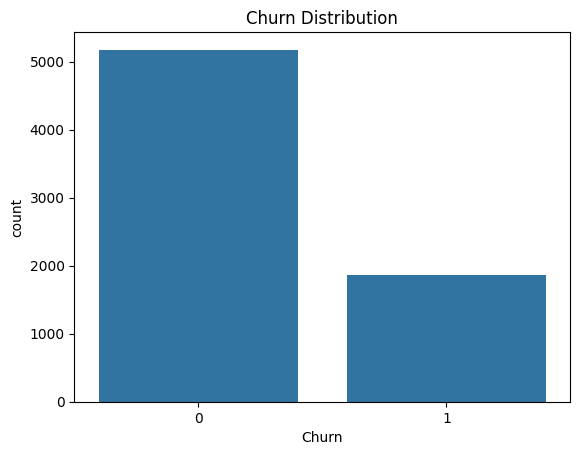

In [15]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


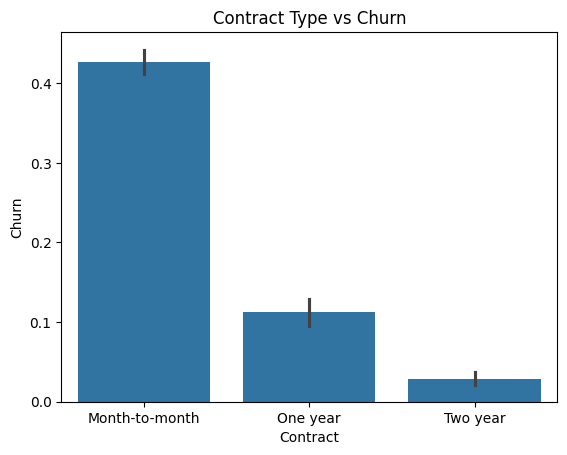

In [16]:
sns.barplot(x="Contract", y="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.show()


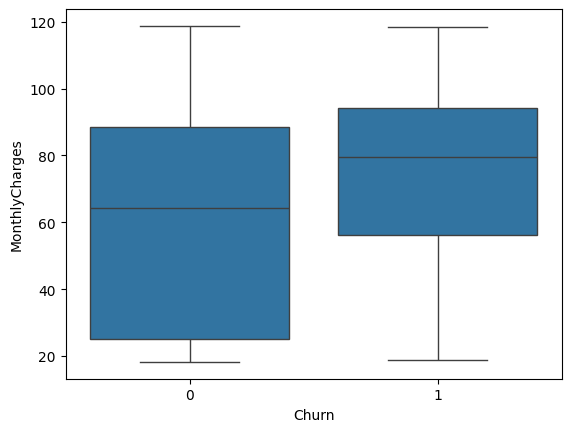

In [17]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()


In [18]:
df_encoded.dtypes


customerID                                 object
gender                                     object
SeniorCitizen                               int64
Partner                                     int64
Dependents                                  int64
tenure                                      int64
PhoneService                                int64
MultipleLines                              object
OnlineSecurity                             object
OnlineBackup                               object
DeviceProtection                           object
TechSupport                                object
StreamingTV                                object
StreamingMovies                            object
PaperlessBilling                            int64
MonthlyCharges                            float64
TotalCharges                              float64
Churn                                       int64
TenureGroup                              category
AvgMonthlySpend                           float64


In [19]:
numeric_df = df_encoded.select_dtypes(include=['number'])


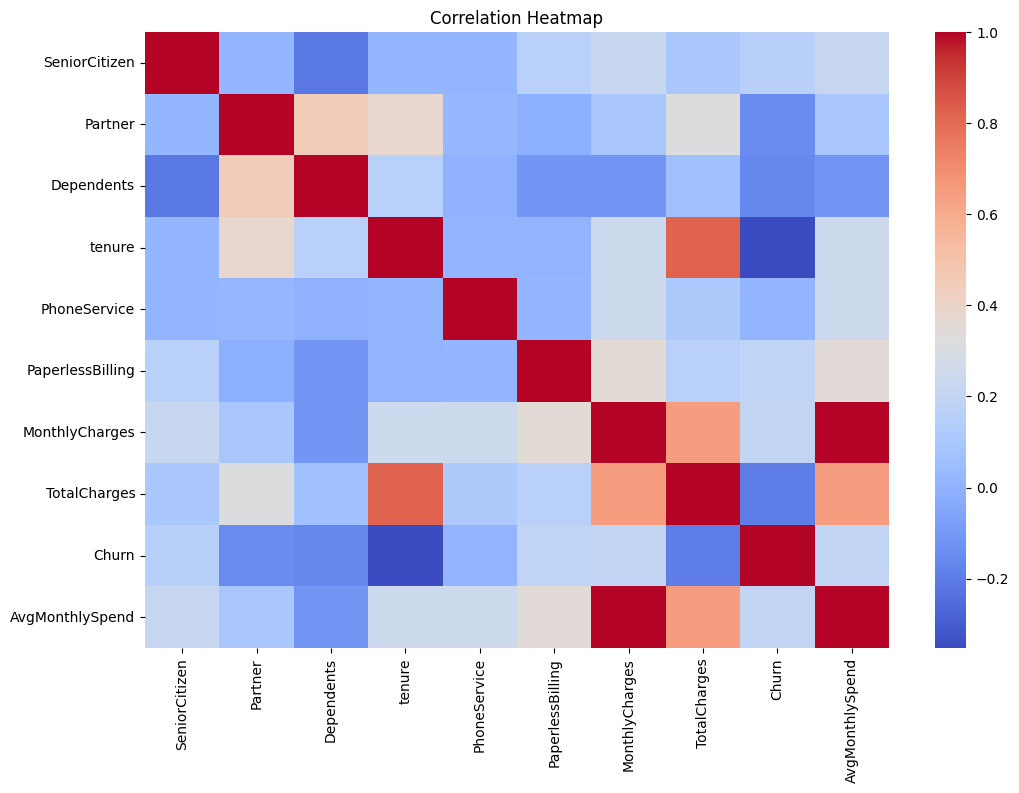

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [21]:
df_encoded.to_csv("cleaned_telco_churn.csv", index=False)

#Top 5 Insights:

1. Most customers stay with the telecom provider, but a noticeable percentage churns, highlighting retention challenges.
2. Customers on month-to-month contracts have a significantly higher churn rate than those on long-term contracts.
3. Higher monthly charges are strongly associated with customer churn.
4. Long-tenure customers are more loyal, while newer customers are more likely to churn early.
5. Fiber-optic internet users and paperless billing customers show slightly higher churn trends.


In [22]:
#TASK 4: Netflix Titles Dataset – EDA

In [23]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Convert Churn to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

C:\Users\Admin\AppData\Local\Temp\ipykernel_6172\3748103335.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [24]:
df_encoded = pd.get_dummies(df, drop_first=True)

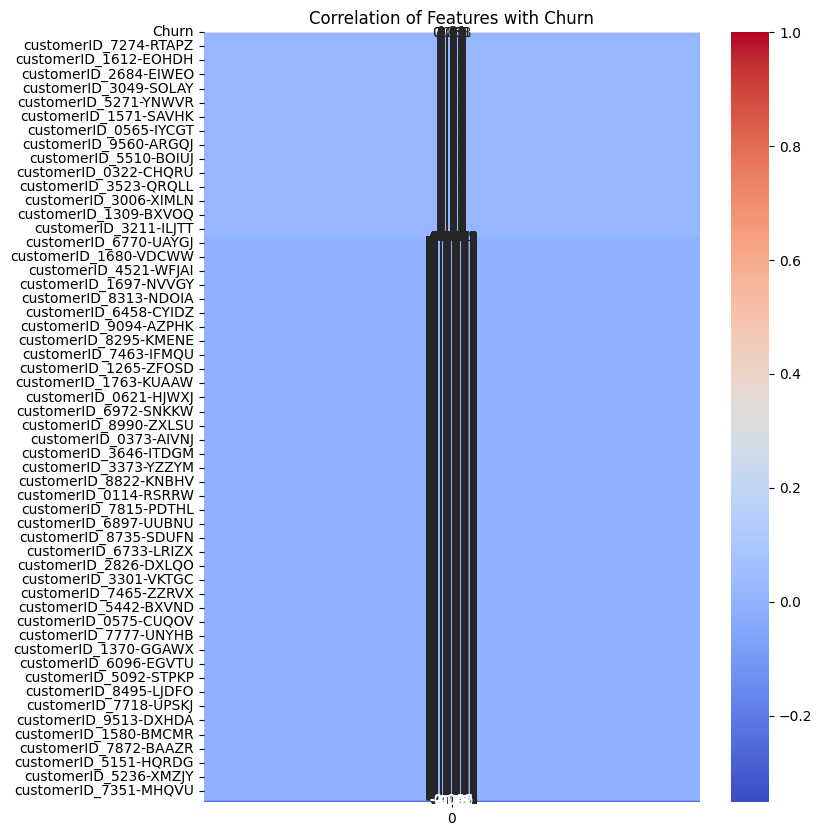

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,10))

churn_corr = df_encoded.corrwith(df_encoded["Churn"]).sort_values(ascending=False)

sns.heatmap(churn_corr.to_frame(), cmap="coolwarm", annot=True)

plt.title("Correlation of Features with Churn")
plt.show()

### 🔍 Top 5 Insights from Customer Churn Analysis

1. Customers with month-to-month contracts show higher churn rates.
2. Higher monthly charges are strongly associated with customer churn.
3. Long-tenure customers are more loyal and less likely to churn.
4. Fiber optic internet users have higher churn compared to DSL users.
5. Customers using paperless billing churn slightly more than others.
